In [1]:
import pandas as pd

df = pd.read_csv("gold_analysis_sample.csv")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("gold_analysis_sample.csv")

df.head()


,playerid,platform,completion_ratio,normalized_score,engagement_score
0,2329278,XBOX,0.134146,0.055862,0.102833
1,76561198977284380,STEAM,0.397849,NaN,0.397849
2,1800385,PS,0.976744,0.346939,0.724822
3,791967,XBOX,0.157895,0.041811,0.111461
4,330498,PS,0.680000,0.320296,0.536118


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nPlatform counts:")
print(df["platform"].value_counts())

df.describe(include="all")

Shape: (5000, 5)

Columns:
Index(['playerid', 'platform', 'completion_ratio', 'normalized_score',
       'engagement_score'],
      dtype='object')

Missing values:
playerid              0
platform              0
completion_ratio      0
normalized_score    690
engagement_score      0
dtype: int64

Platform counts:
platform
XBOX     2168
PS       2142
STEAM     690
Name: count, dtype: int64


,playerid,platform,completion_ratio,normalized_score,engagement_score
count,5.000000e+03,5000,5000.000000,4310.000000,5000.000000
unique,NaN,3,NaN,NaN,NaN
top,NaN,XBOX,NaN,NaN,NaN
freq,NaN,2168,NaN,NaN,NaN
mean,1.056545e+16,NaN,0.309127,0.186540,0.264954
std,2.640860e+16,NaN,0.268417,0.146648,0.191248
min,1.786000e+03,NaN,0.001506,0.022239,0.001506
25%,7.492930e+05,NaN,0.080000,0.039535,0.120362
50%,1.311325e+06,NaN,0.229041,0.107918,0.219885
75%,3.311109e+06,NaN,0.483871,0.323959,0.384553


/tmp/ipykernel_2740/3418420278.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="platform", y="engagement_score", palette="mako")


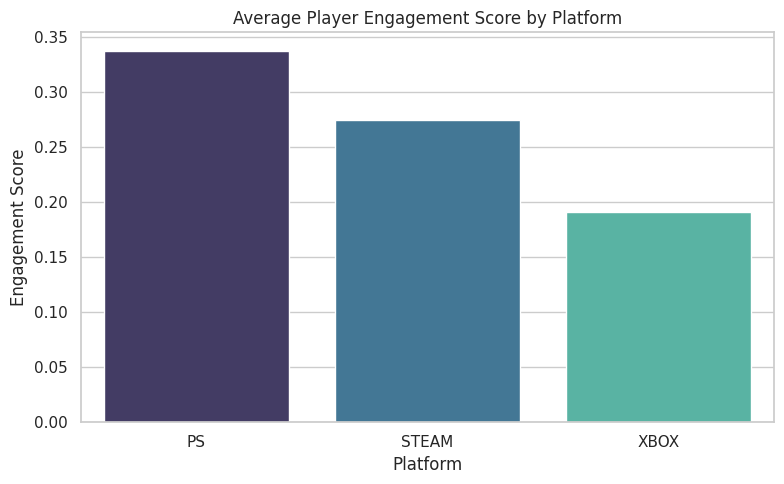

In [15]:
summary = df.groupby("platform")["engagement_score"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="platform", y="engagement_score", palette="mako")

plt.title("Average Player Engagement Score by Platform")
plt.xlabel("Platform")
plt.ylabel("Engagement Score")

plt.tight_layout()
plt.show()

In [17]:
summary = df.groupby("platform")[["completion_ratio", "normalized_score", "engagement_score"]].mean().reset_index()
summary

,platform,completion_ratio,normalized_score,engagement_score
0,PS,0.340578,0.332028,0.337158
1,STEAM,0.274619,NaN,0.274619
2,XBOX,0.289036,0.042797,0.190541


/tmp/ipykernel_2740/2393136160.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x="platform", y="completion_ratio", palette="viridis")


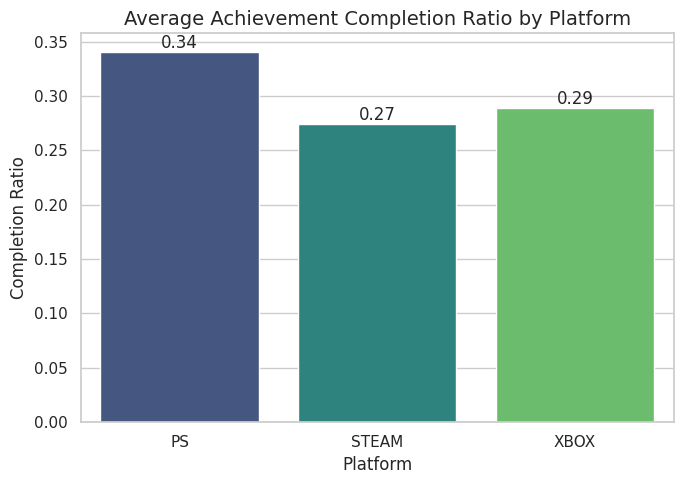

/tmp/ipykernel_2740/2393136160.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x="platform", y="engagement_score", palette="mako")


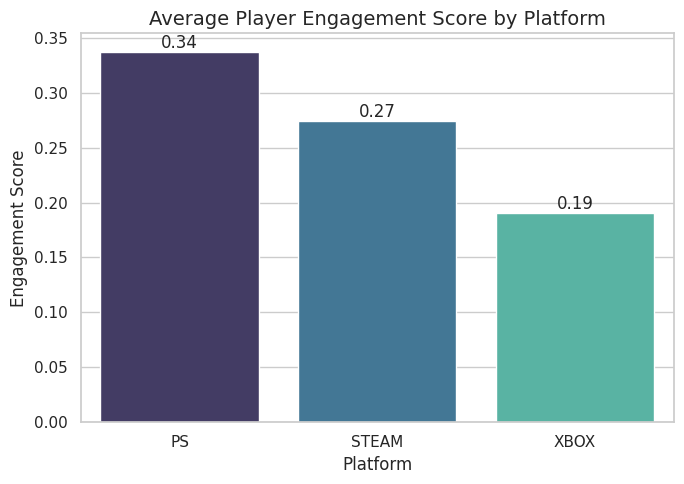

/tmp/ipykernel_2740/2393136160.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x="platform", y="normalized_score", palette="rocket")


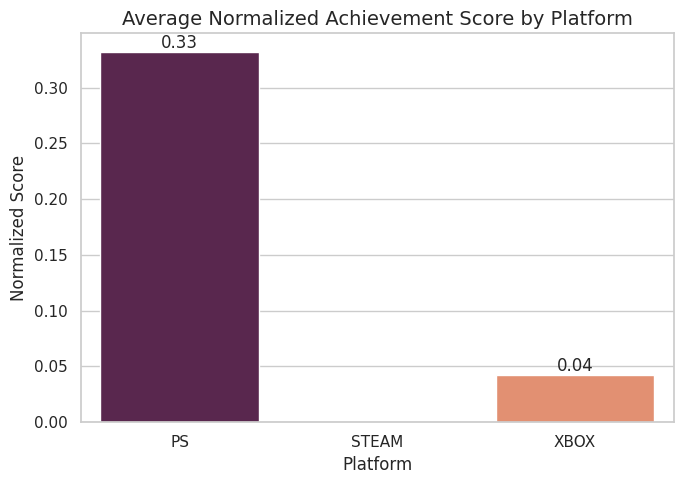

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

# Grafik 1
plt.figure(figsize=(7,5))
ax = sns.barplot(data=summary, x="platform", y="completion_ratio", palette="viridis")

plt.title("Average Achievement Completion Ratio by Platform", fontsize=14)
plt.xlabel("Platform")
plt.ylabel("Completion Ratio")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig("completion_ratio_platform.png", dpi=300)
plt.show()

# Grafik 2
plt.figure(figsize=(7,5))
ax = sns.barplot(data=summary, x="platform", y="engagement_score", palette="mako")

plt.title("Average Player Engagement Score by Platform", fontsize=14)
plt.xlabel("Platform")
plt.ylabel("Engagement Score")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig("engagement_score_platform.png", dpi=300)
plt.show()

# Grafik 3
plt.figure(figsize=(7,5))
ax = sns.barplot(data=summary, x="platform", y="normalized_score", palette="rocket")

plt.title("Average Normalized Achievement Score by Platform", fontsize=14)
plt.xlabel("Platform")
plt.ylabel("Normalized Score")

for p in ax.patches:
    h = p.get_height()
    if not pd.isna(h):
        ax.annotate(f'{h:.2f}',
                    (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom')

plt.tight_layout()
plt.savefig("normalized_score_platform.png", dpi=300)
plt.show()

In [7]:
df.sample(5000).to_csv("gold_analysis_sample.csv", index=False)

In [8]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.describe()

Dataset shape: (5000, 5)

Columns:
Index(['playerid', 'platform', 'completion_ratio', 'normalized_score',
       'engagement_score'],
      dtype='object')


,playerid,completion_ratio,normalized_score,engagement_score
count,5.000000e+03,5000.000000,4310.000000,5000.000000
mean,1.056545e+16,0.309127,0.186540,0.264954
std,2.640860e+16,0.268417,0.146648,0.191248
min,1.786000e+03,0.001506,0.022239,0.001506
25%,7.492930e+05,0.080000,0.039535,0.120362
50%,1.311325e+06,0.229041,0.107918,0.219885
75%,3.311109e+06,0.483871,0.323959,0.384553
max,7.656120e+16,1.000000,0.529138,1.000000


/tmp/ipykernel_2740/2899735423.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x="platform", y="completion_ratio", palette="viridis")


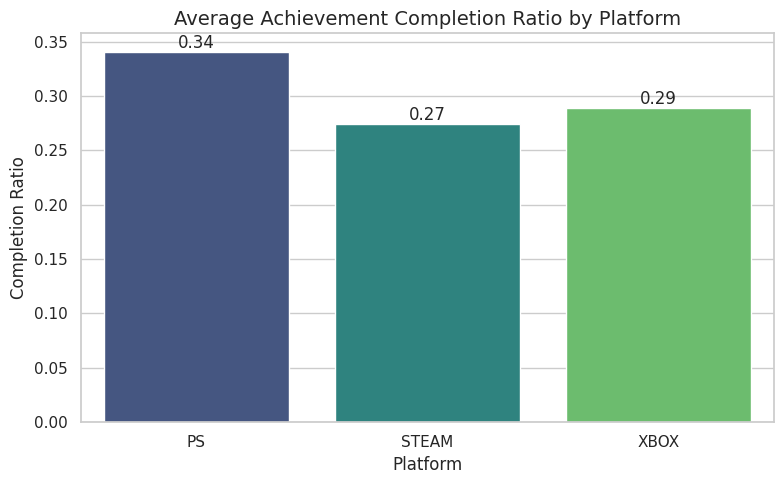

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

summary = df.groupby("platform")["completion_ratio"].mean().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=summary, x="platform", y="completion_ratio", palette="viridis")

plt.title("Average Achievement Completion Ratio by Platform", fontsize=14)
plt.xlabel("Platform")
plt.ylabel("Completion Ratio")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

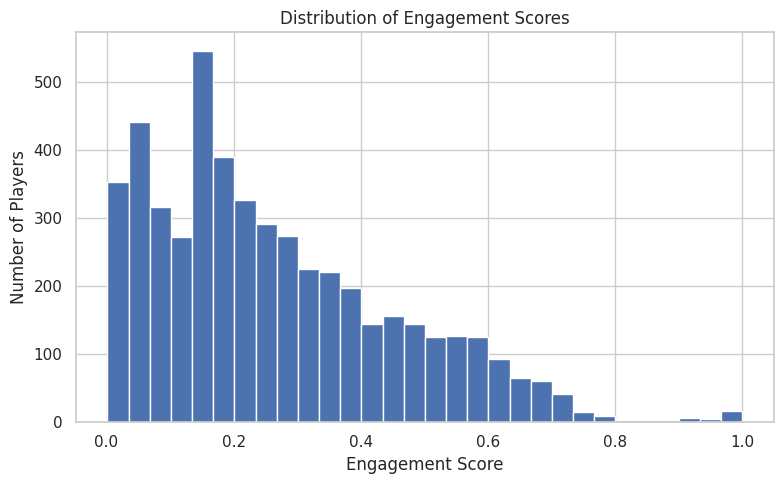

In [19]:
plt.figure(figsize=(8,5))

df["engagement_score"].hist(bins=30)

plt.title("Distribution of Engagement Scores")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

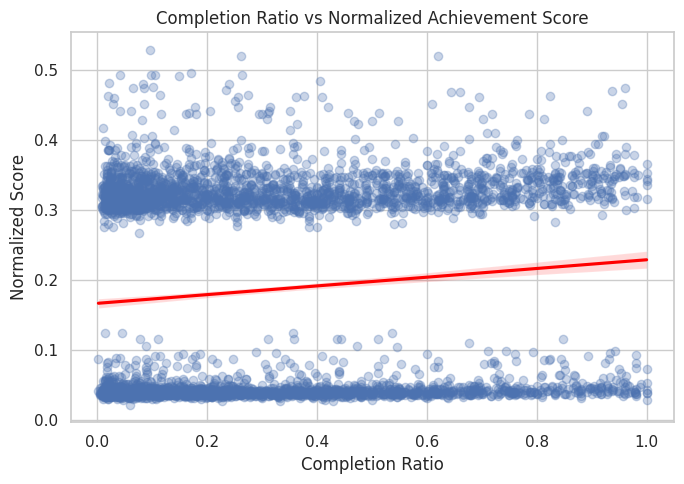

In [21]:
import seaborn as sns

plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x="completion_ratio",
    y="normalized_score",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Completion Ratio vs Normalized Achievement Score")
plt.xlabel("Completion Ratio")
plt.ylabel("Normalized Score")

plt.tight_layout()
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ml_df = df[df["normalized_score"].notna()].copy()

X = ml_df[["completion_ratio"]]
y = ml_df["normalized_score"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)
r2 = r2_score(y, pred)

print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {r2:.4f}")

Coefficient: 0.0623
Intercept: 0.1669
R² Score: 0.0131
